# Radiation Testing of the RP2040 and RP2350 Microcontroller Chips
Testing done with Gamma Radiation at VPT Rad

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.facecolor": (1,1,1,1),
    "axes.facecolor": (1,1,1,1),
    "savefig.facecolor": (1,1,1,1),
    "figure.dpi": 600
})
plt.style.use('tableau-colorblind10')

## Dynamic Testing
Tested 2 at a time 3 times 
1. Pico and Pico 2 (ARM) - Pico pulled first
3. Pico 2 (RISC-V) and Pico - ended together 
4. Pico 2 (ARM) and Pico 2 (RISC-V) - riscv pulled first 

In [2]:
class DynamicTest:
    def __init__(self, mcu: str, death: float, restart: list[float], crash: list[float], note: str):
        self.mcu = mcu 
        self.death = death
        self.restart = restart
        self.crash = crash 
        self.note = note 

## Data

In [3]:
# notes on performance
# test 1 
test1 = pd.read_csv(os.path.join("data", "run_1_data_out.csv"), skipinitialspace=True)
test1_pico1 = DynamicTest(mcu="rp2040", 
                          death=111,
                          restart=[80, 85, 89, 97, 105, 111], 
                          crash=[],
                          note="Died fully"
                         )

test1_pico2_arm = DynamicTest(mcu="rp2350-arm", 
                              death=151,
                              restart=[151],
                              crash=[100, 118, 121, 125, 129, 135, 150], 
                              note=""
                             )

# test 2 
test2 = pd.read_csv(os.path.join("data", "run_2_data_out.csv"), skipinitialspace=True)
test2_pico2_riscv = DynamicTest(mcu="rp2350-riscv",
                          death=93,
                          restart=[50, 58, 80, 82, 88, 89, 91, 93],
                          crash=[],
                          note="flickering in and out of bootsel and dies when being irradiated and turns back on when not being irradiated"
                               )

test2_pico1 = DynamicTest(mcu="rp2040", 
                          death=93,
                          restart=[86, 89, 93],
                          crash=[77.5, 82, 91],
                          note="flickering in and out of bootsel and dies when being irradiated and turns back on when not being irradiated"
                         )

# test 3 
test3 = pd.read_csv(os.path.join("data", "run_3_data_out.csv"), skipinitialspace=True)
test3_pico2_arm = DynamicTest(mcu="rp2350-arm", 
                              death=195, 
                              restart=[146],
                              crash=[100, 118, 148, 192, 195],
                              note="died fully"
                             )

test3_pico2_riscv = DynamicTest(mcu="rp2350-riscv", 
                                death=111, 
                                restart=[50],
                                crash=[100, 105, 110, 110, 111],
                                note="can go into bootcel and can flash, comes back after stops getting iradiated"
                               )

# general processing 
for df in [test1, test2, test3]: 
    total = 0
    total_duration_time = []
    for t in df["(seconds)"]:
        total += t 
        total_duration_time.append(total)
    
    df["Total Duration Time (s)"] = total_duration_time

    df["Cumulative Dose krad(Si)"] = df["Cumulative Dose rad(Si)"] / 1000

In [4]:
# tools 

combined_rad_max = max(test1["Cumulative Dose krad(Si)"].max(), 
            test2["Cumulative Dose krad(Si)"].max(), 
            test3["Cumulative Dose krad(Si)"].max())
print("Scale max:", combined_rad_max)

CHECKPOINT_COLOR = "#006BA4" # cerulean blue 
RESTART_COLOR = "#5F9ED1" # picton blue
CRASH_COLOR = "#FF800E" # pumpkin orange
DEATH_COLOR = "black" 

def single_graph_dynamic_test(ax, df, title, mcu): 
    EVENT_LINE_WIDTH = 1 #0.5
    
    def krad_to_time(krad: float) -> float:
        return (1/75) * (krad * 1000)

    x = [0] + list(df["Total Duration Time (s)"])
    y = [0] + list(df["Cumulative Dose krad(Si)"])
    ax.plot(x,y, #df["Total Duration Time (s)"],df["Cumulative Dose krad(Si)"], 
            marker='o', 
            markersize=5,
            color=CHECKPOINT_COLOR, 
            label="Test Checkpoints"
           )
    ax.set_ylabel("Cumulative Dose (krad(Si))")
    ax.set_xlabel("Total Duration Time (s)")
    ax.set_title(title)

    # set max to match test max 
    ax.set_xlim(left=-krad_to_time(combined_rad_max) * 0.05, 
                right=krad_to_time(combined_rad_max) * 1.05)
    ax.set_ylim(bottom=-combined_rad_max * 0.05, 
                top=combined_rad_max * 1.05)
    
    # graph reboots
    y_min, y_max = ax.get_ylim()
    x_min, x_max = ax.get_xlim()
    
    restart_times = [krad_to_time(x) for x in mcu.restart]
    ax.vlines(restart_times, y_min, y_max, 
              color=RESTART_COLOR,
              linestyles='dashed',
              linewidth=EVENT_LINE_WIDTH)
    ax.plot(restart_times, mcu.restart, 
            marker="o", 
            markersize=5,
            color=RESTART_COLOR, 
            linestyle="None", 
            label="Restart")
    # graph crashes 
    crash_times = [krad_to_time(x) for x in mcu.crash]
    ax.vlines(crash_times, y_min, y_max,
              color=CRASH_COLOR,
              linestyles='dashed',
              linewidth=EVENT_LINE_WIDTH)
    ax.plot(crash_times, mcu.crash, 
            marker="o", 
            markersize=5,
            color=CRASH_COLOR, 
            linestyle="None",
            label="Crash")
    # graph death 
    ax.vlines(krad_to_time(mcu.death), y_min, y_max,
              color=DEATH_COLOR,
              linestyles='dashed',
              linewidth=EVENT_LINE_WIDTH)
    ax.plot(krad_to_time(mcu.death), mcu.death, 
            marker='X', 
            markersize=10,
            color=DEATH_COLOR, 
            linestyle="None", 
            label="Death")
    ax.text(krad_to_time(mcu.death), mcu.death-6, f" {mcu.death} krad(Si)", 
           horizontalalignment='left', 
           verticalalignment='top')
    
    ax.legend()

Scale max: 207.0


## RP2040

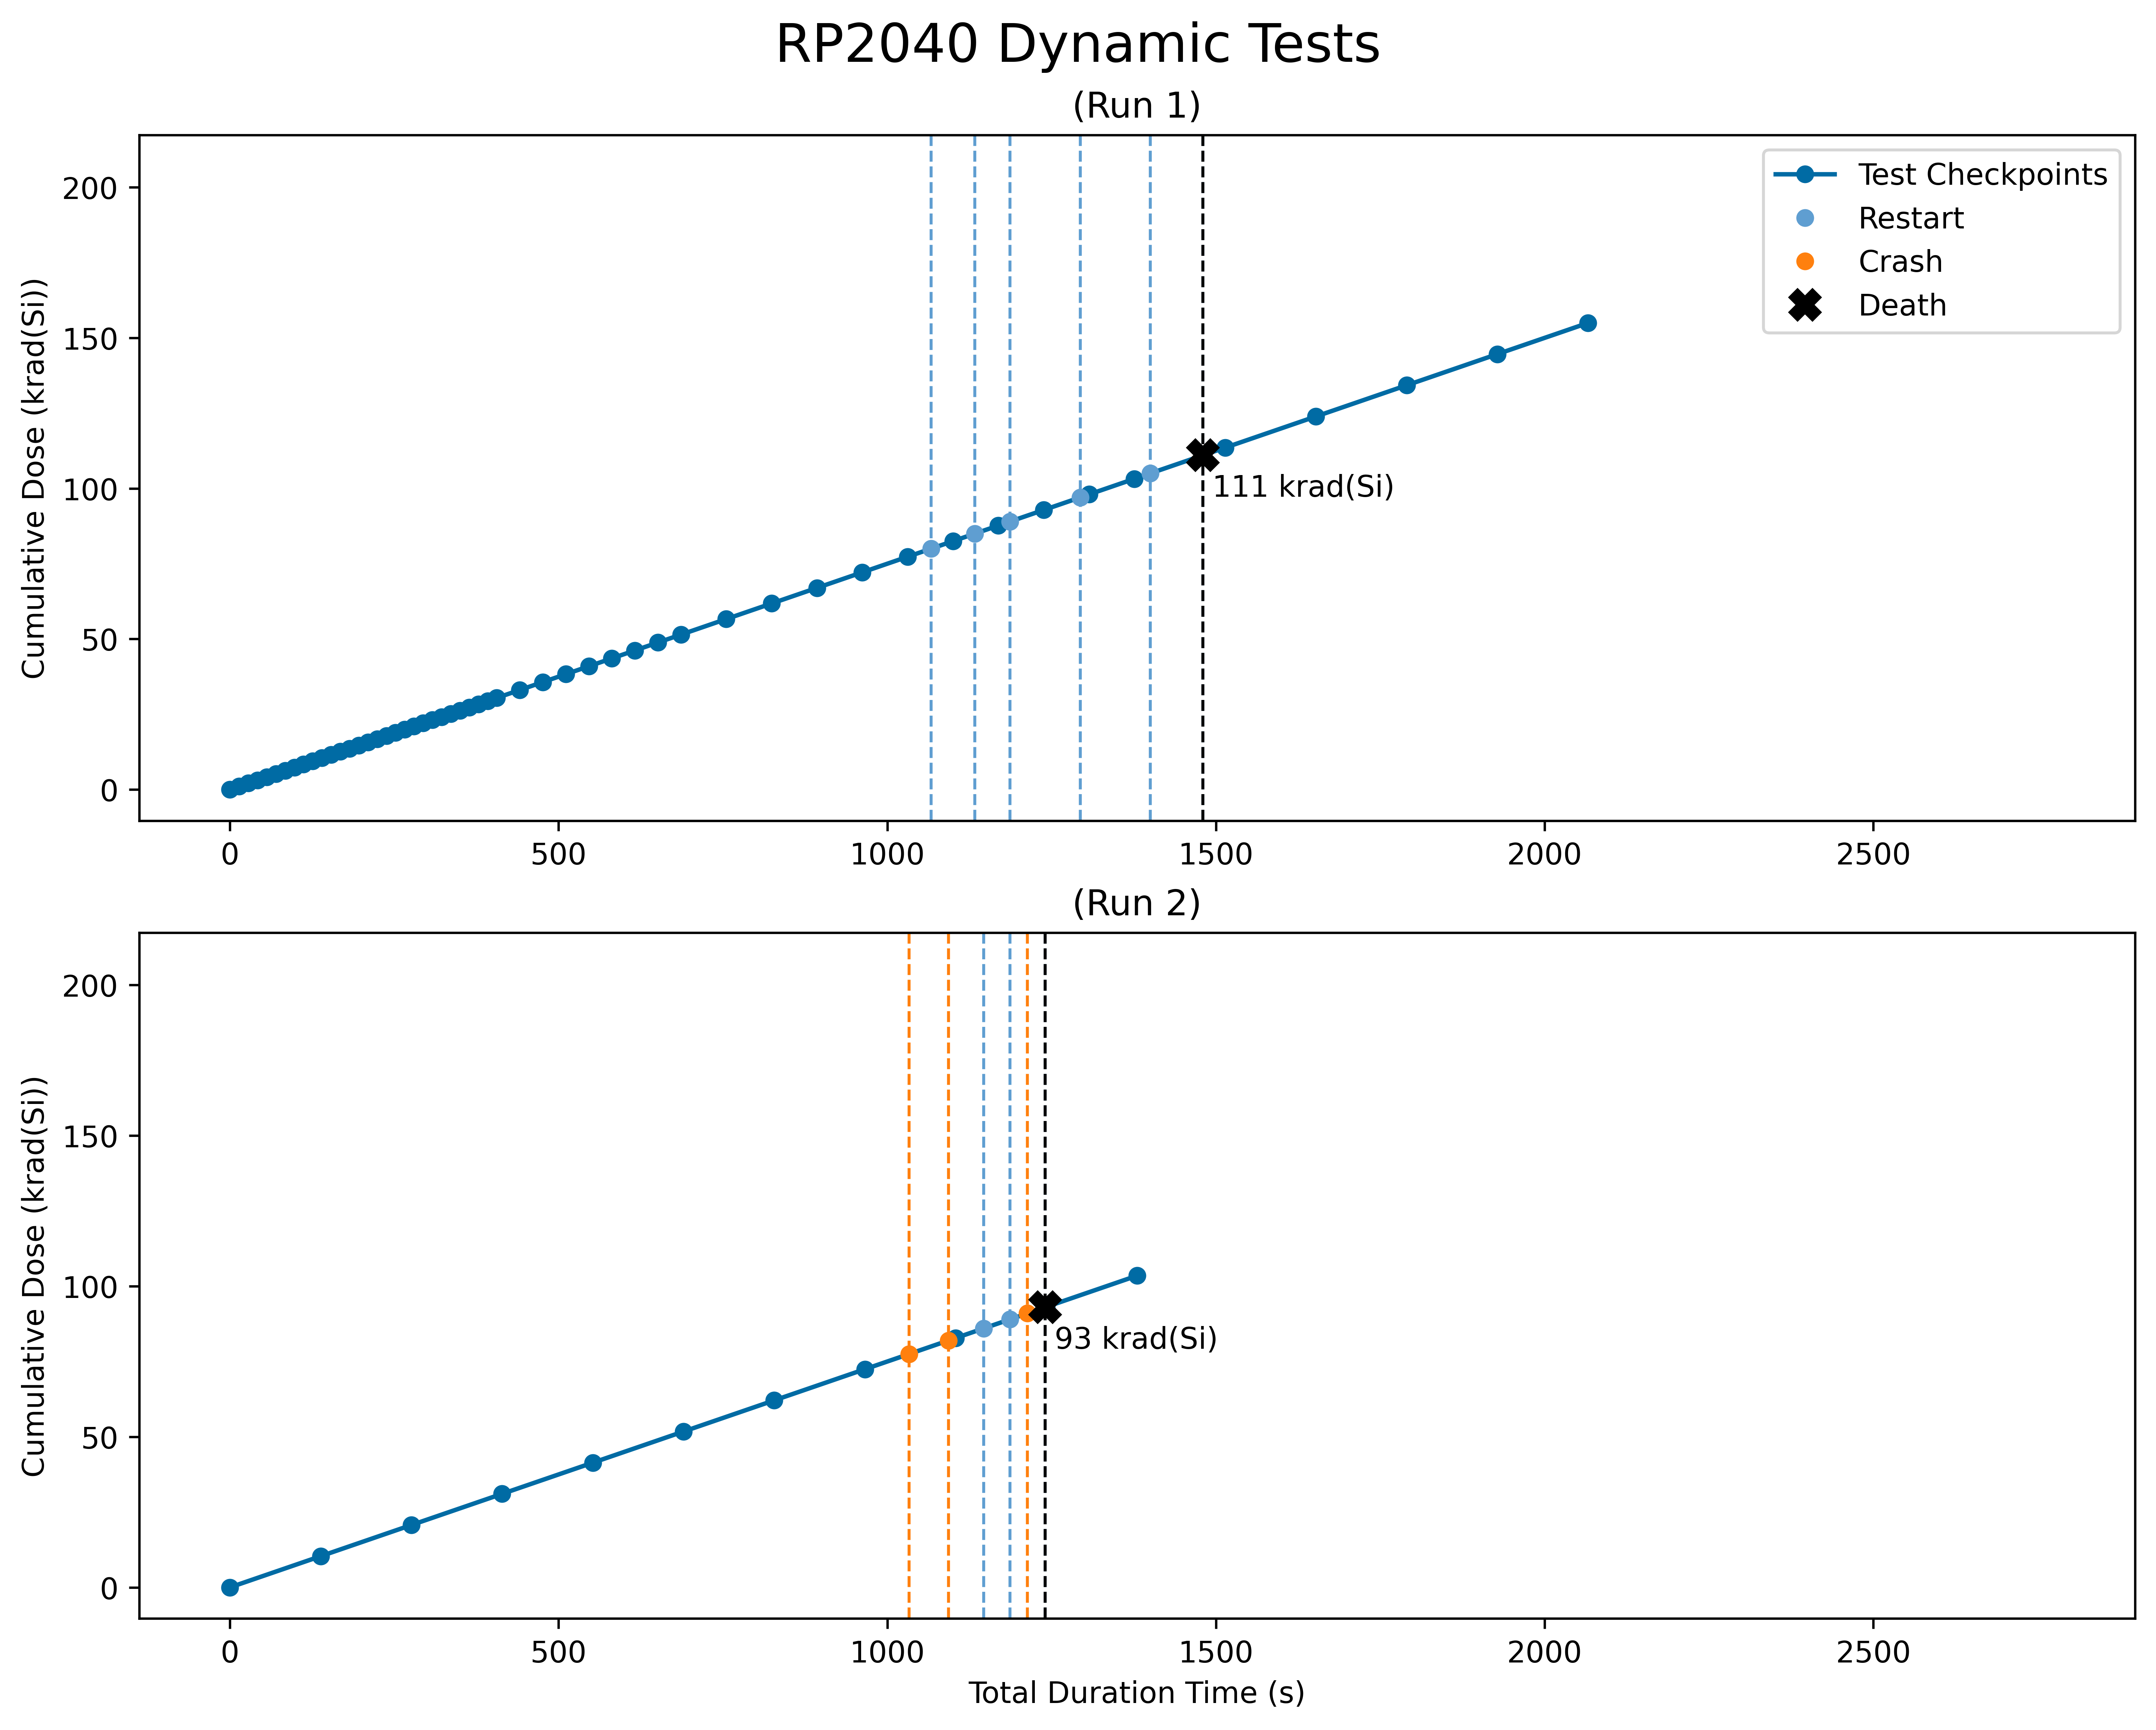

In [5]:
    
fig, axes = plt.subplots(2,1,figsize=(10,8), layout='constrained')
axes = axes.flatten()
single_graph_dynamic_test(axes[0], test1, "(Run 1)", test1_pico1)
axes[0].set_xlabel("")
single_graph_dynamic_test(axes[1], test2, "(Run 2)", test2_pico1)
axes[1].get_legend().remove()
fig.suptitle("RP2040 Dynamic Tests", fontsize=18)

plt.show()


## RP2350 (ARM)

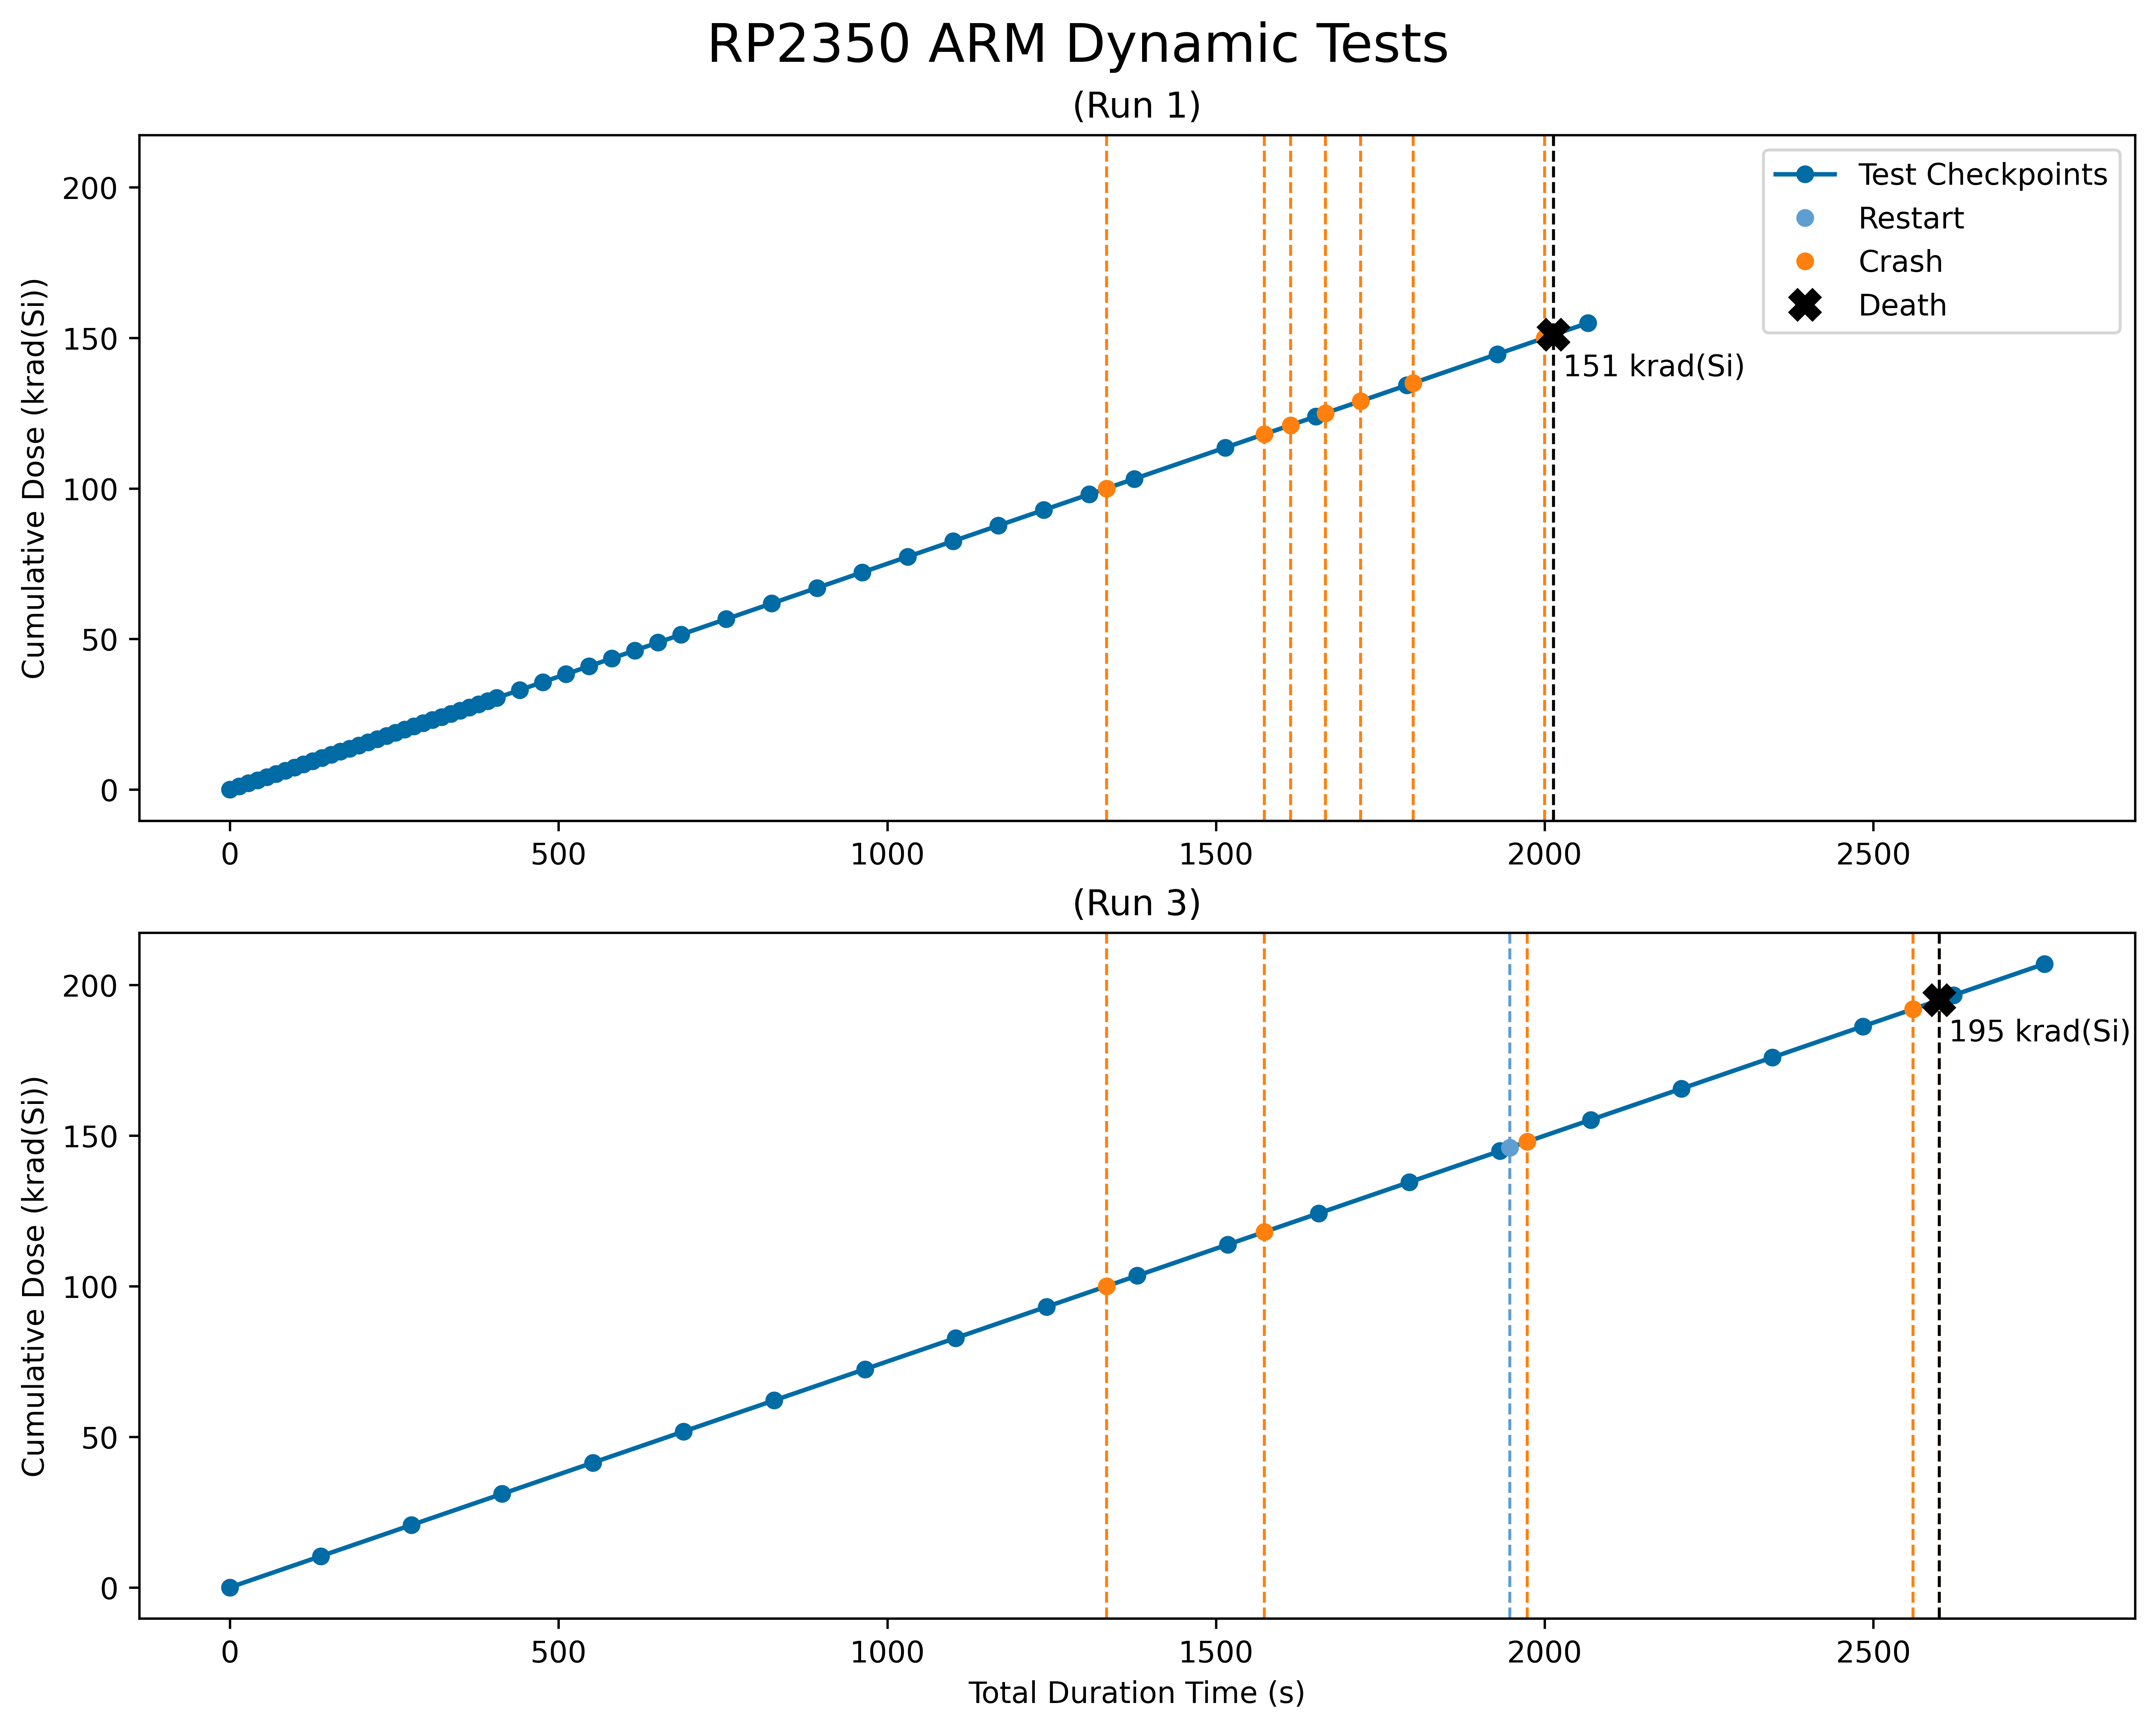

In [6]:
    
fig, axes = plt.subplots(2,1,figsize=(10,8), layout='constrained')
axes = axes.flatten()
single_graph_dynamic_test(axes[0], test1, "(Run 1)", test1_pico2_arm)
axes[0].set_xlabel("")
single_graph_dynamic_test(axes[1], test3, "(Run 3)", test3_pico2_arm)
axes[1].get_legend().remove()
fig.suptitle("RP2350 ARM Dynamic Tests", fontsize=18)

plt.show()


## RP2350 (RISC-V)

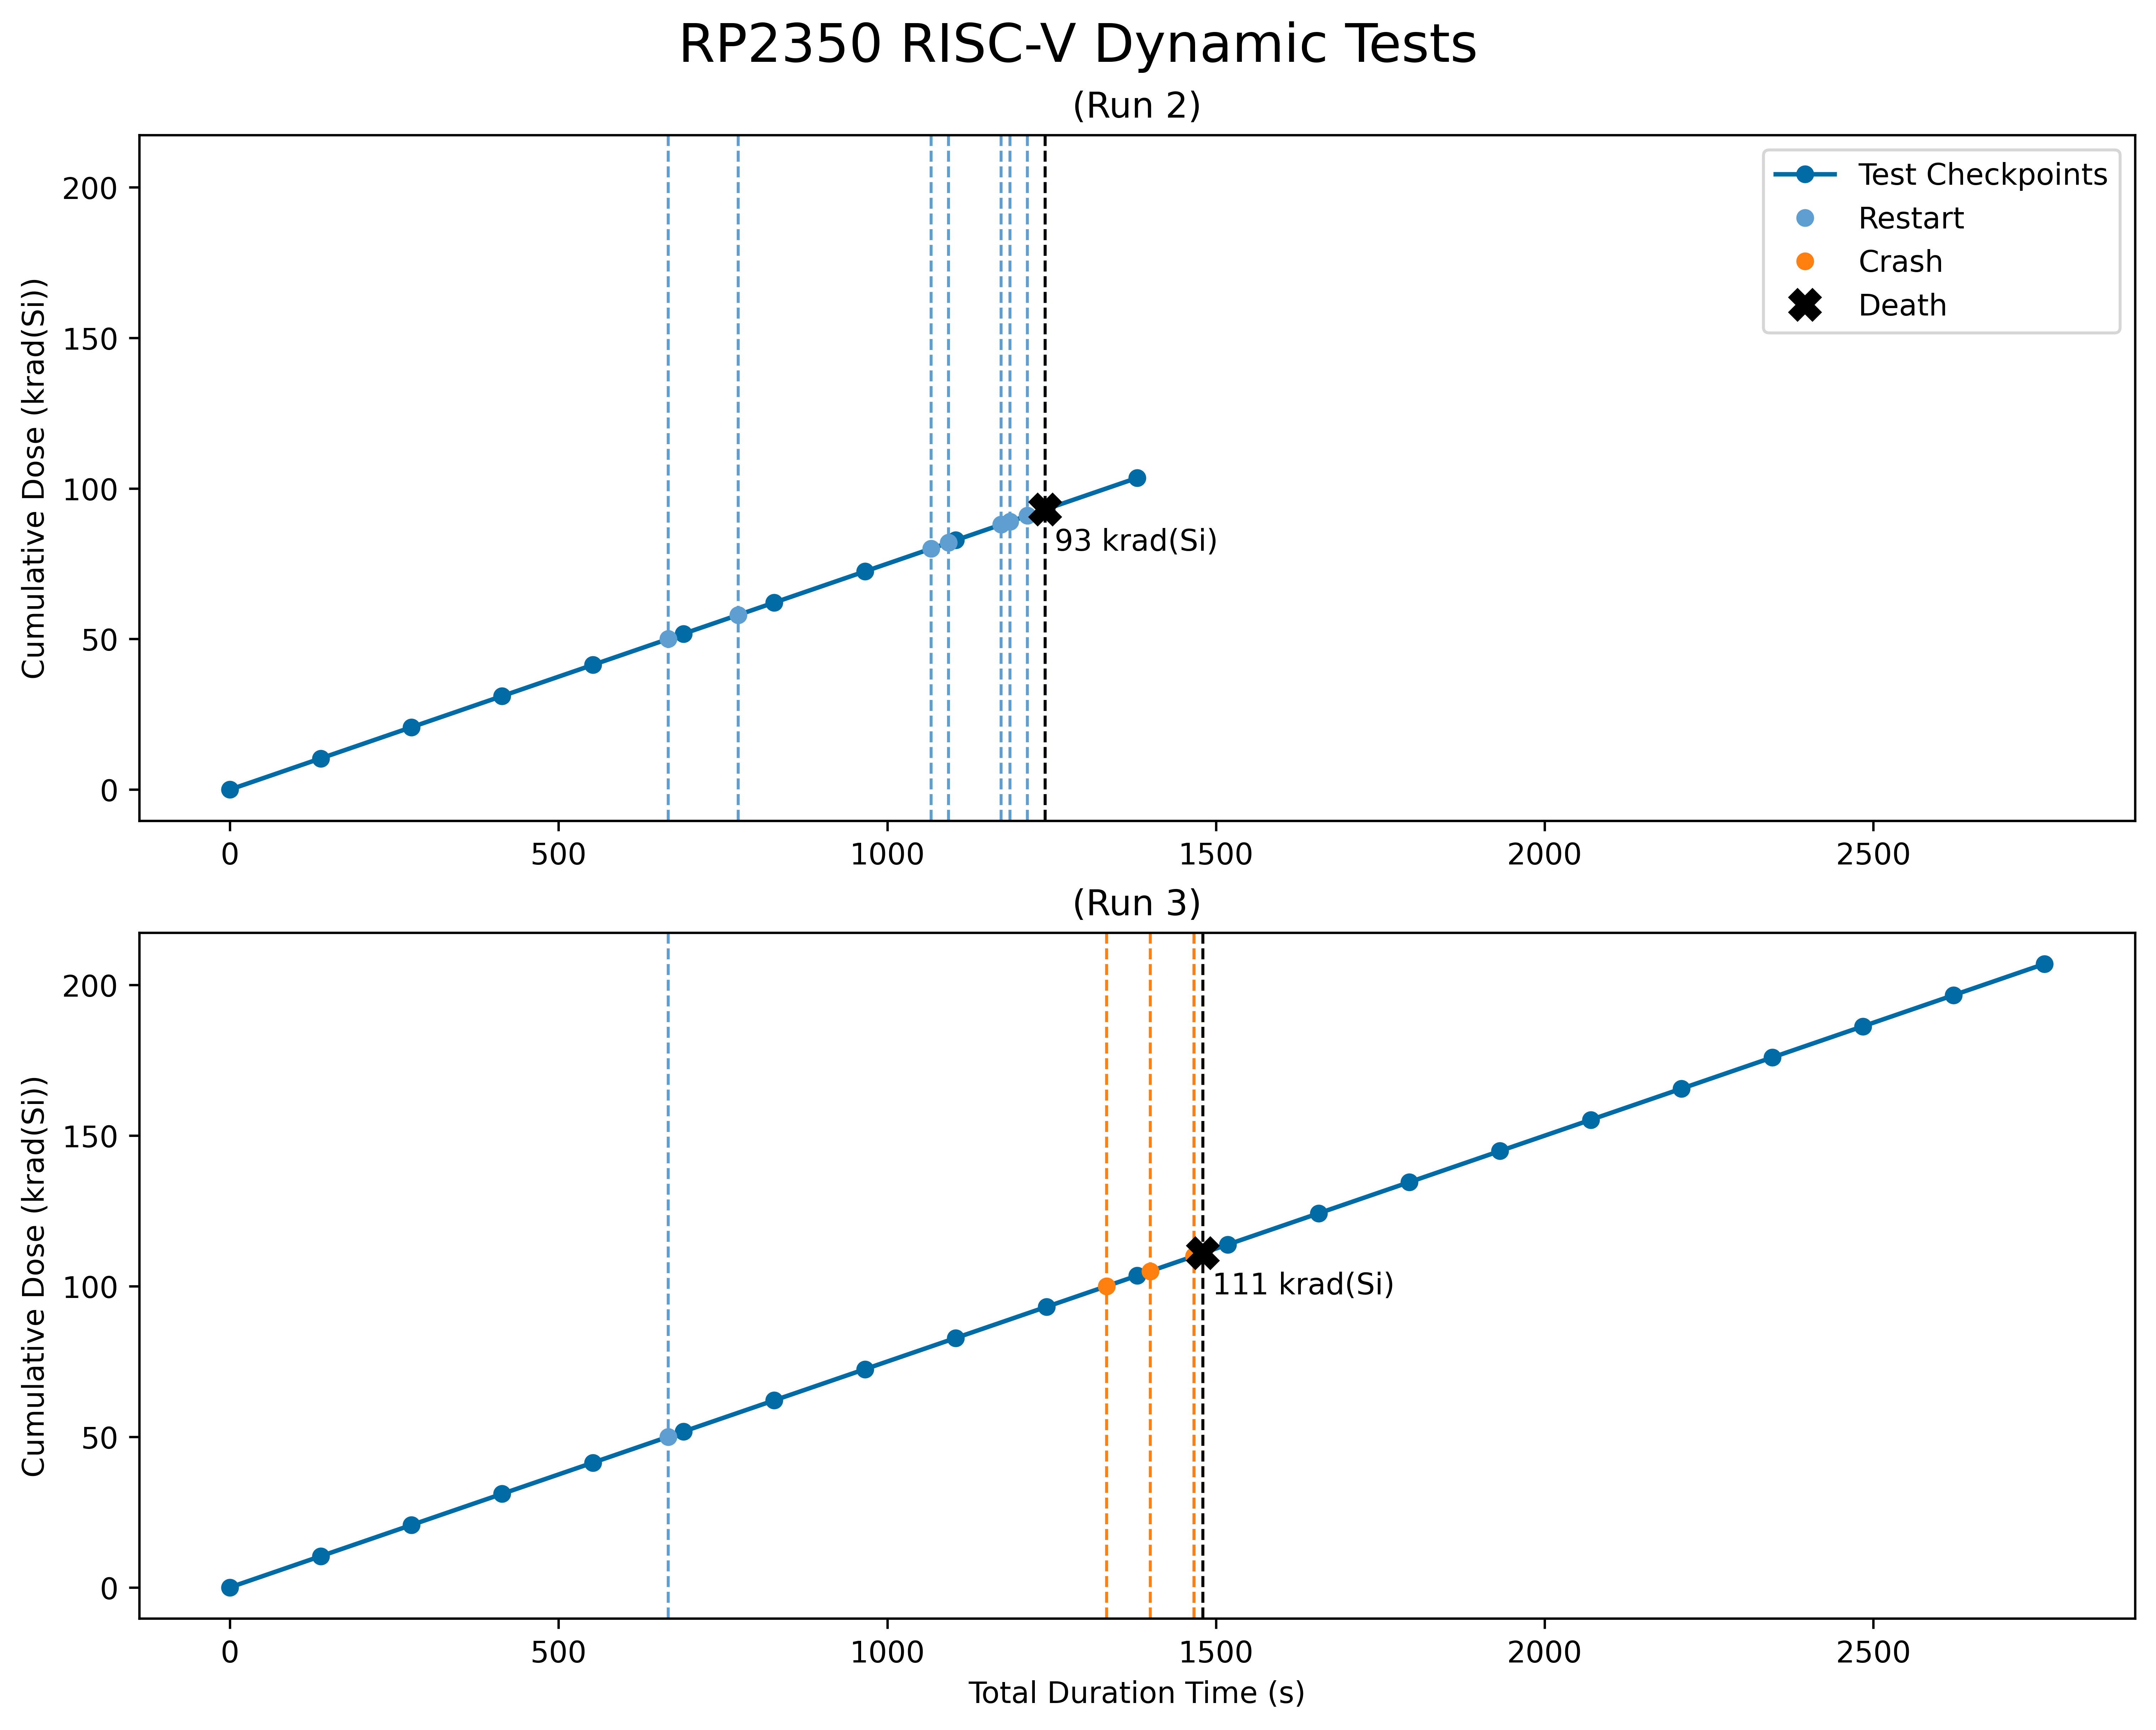

In [7]:
    
fig, axes = plt.subplots(2,1,figsize=(10,8), layout='constrained')
axes = axes.flatten()
single_graph_dynamic_test(axes[0], test2, "(Run 2)", test2_pico2_riscv)
axes[0].set_xlabel("")
single_graph_dynamic_test(axes[1], test3, "(Run 3)", test3_pico2_riscv)
fig.suptitle("RP2350 RISC-V Dynamic Tests", fontsize=18)
axes[1].get_legend().remove()

plt.show()


# Static Step Testing
4. SN 5,6,9 (replaced 9 with 7) - Pico 2 
5. SN 0,1,2 - Pico 1 
6. SN 9
7. SN 1,2 and SN 5,6

In [8]:
# mA
# krad
pico1_runs = [
    [[0, 30, 40, 45, 50],
     [94.1, 92.6, 94.6, 97.1, 100.8],
     3], 
    [[50, 62.5, 68.75, 75],
     [75.2, 92.7, 101.5, 116.2],
     3],
    [[75, 87.5, 93.75, 100], 
     [84.9, 121.9, 176.3, 176.2],
     3]
]

pico2_runs = [
    [[0, 30, 40, 45, 50],
     [71, 70.6, 73, 75.8, 80.4],
     3],
    [[50, 62.5, 68.75, 75],
     [47.3, 61.7, 73.5, 92.4],
     2],
    [[75, 87.5, 93.75, 100],
     [76.4, 109.5, 127.8, 144.9],
     3]
]

pico2_run_extra = [
    [[75, 87.5, 93.75, 100], 
    [10.4, 15.7, 22.6, 27.2],
    1]
]

final_combo = [
    [[100, 150, 175, 200], 
    [332.2, 566.3, 653.4, 716.4],
    4]
]


In [9]:
# find shared max height 
max_y = 0 
for run in pico1_runs + pico2_runs + pico2_run_extra:
    max_y = max(max_y, max(run[1]) / run[2])

print("Shared max_y:", max_y)
max_y = max_y * 1.05
print("Used max_y:", max_y)

# plot runs 
def plot_current_curves(runs, title):
    # pico 1 first runs 
    fig, ax = plt.subplots(figsize=(8,5))
    
    def add_average_current_curve(ax, run_data, label):
        ax.plot(run_data[0], [c / run_data[2] for c in run_data[1]],
                label=label)

    ax.set_ylim(top=max_y)
    
    ax.set_title(title) 
    ax.set_xlabel("Dose (rad(Si))")
    ax.set_ylabel("Current (mA)")
    
    for i in range(len(runs)): 
        add_average_current_curve(ax, runs[i], f"Run {i}")
    
    ax.legend()
    
    plt.show()

Shared max_y: 58.76666666666667
Used max_y: 61.70500000000001


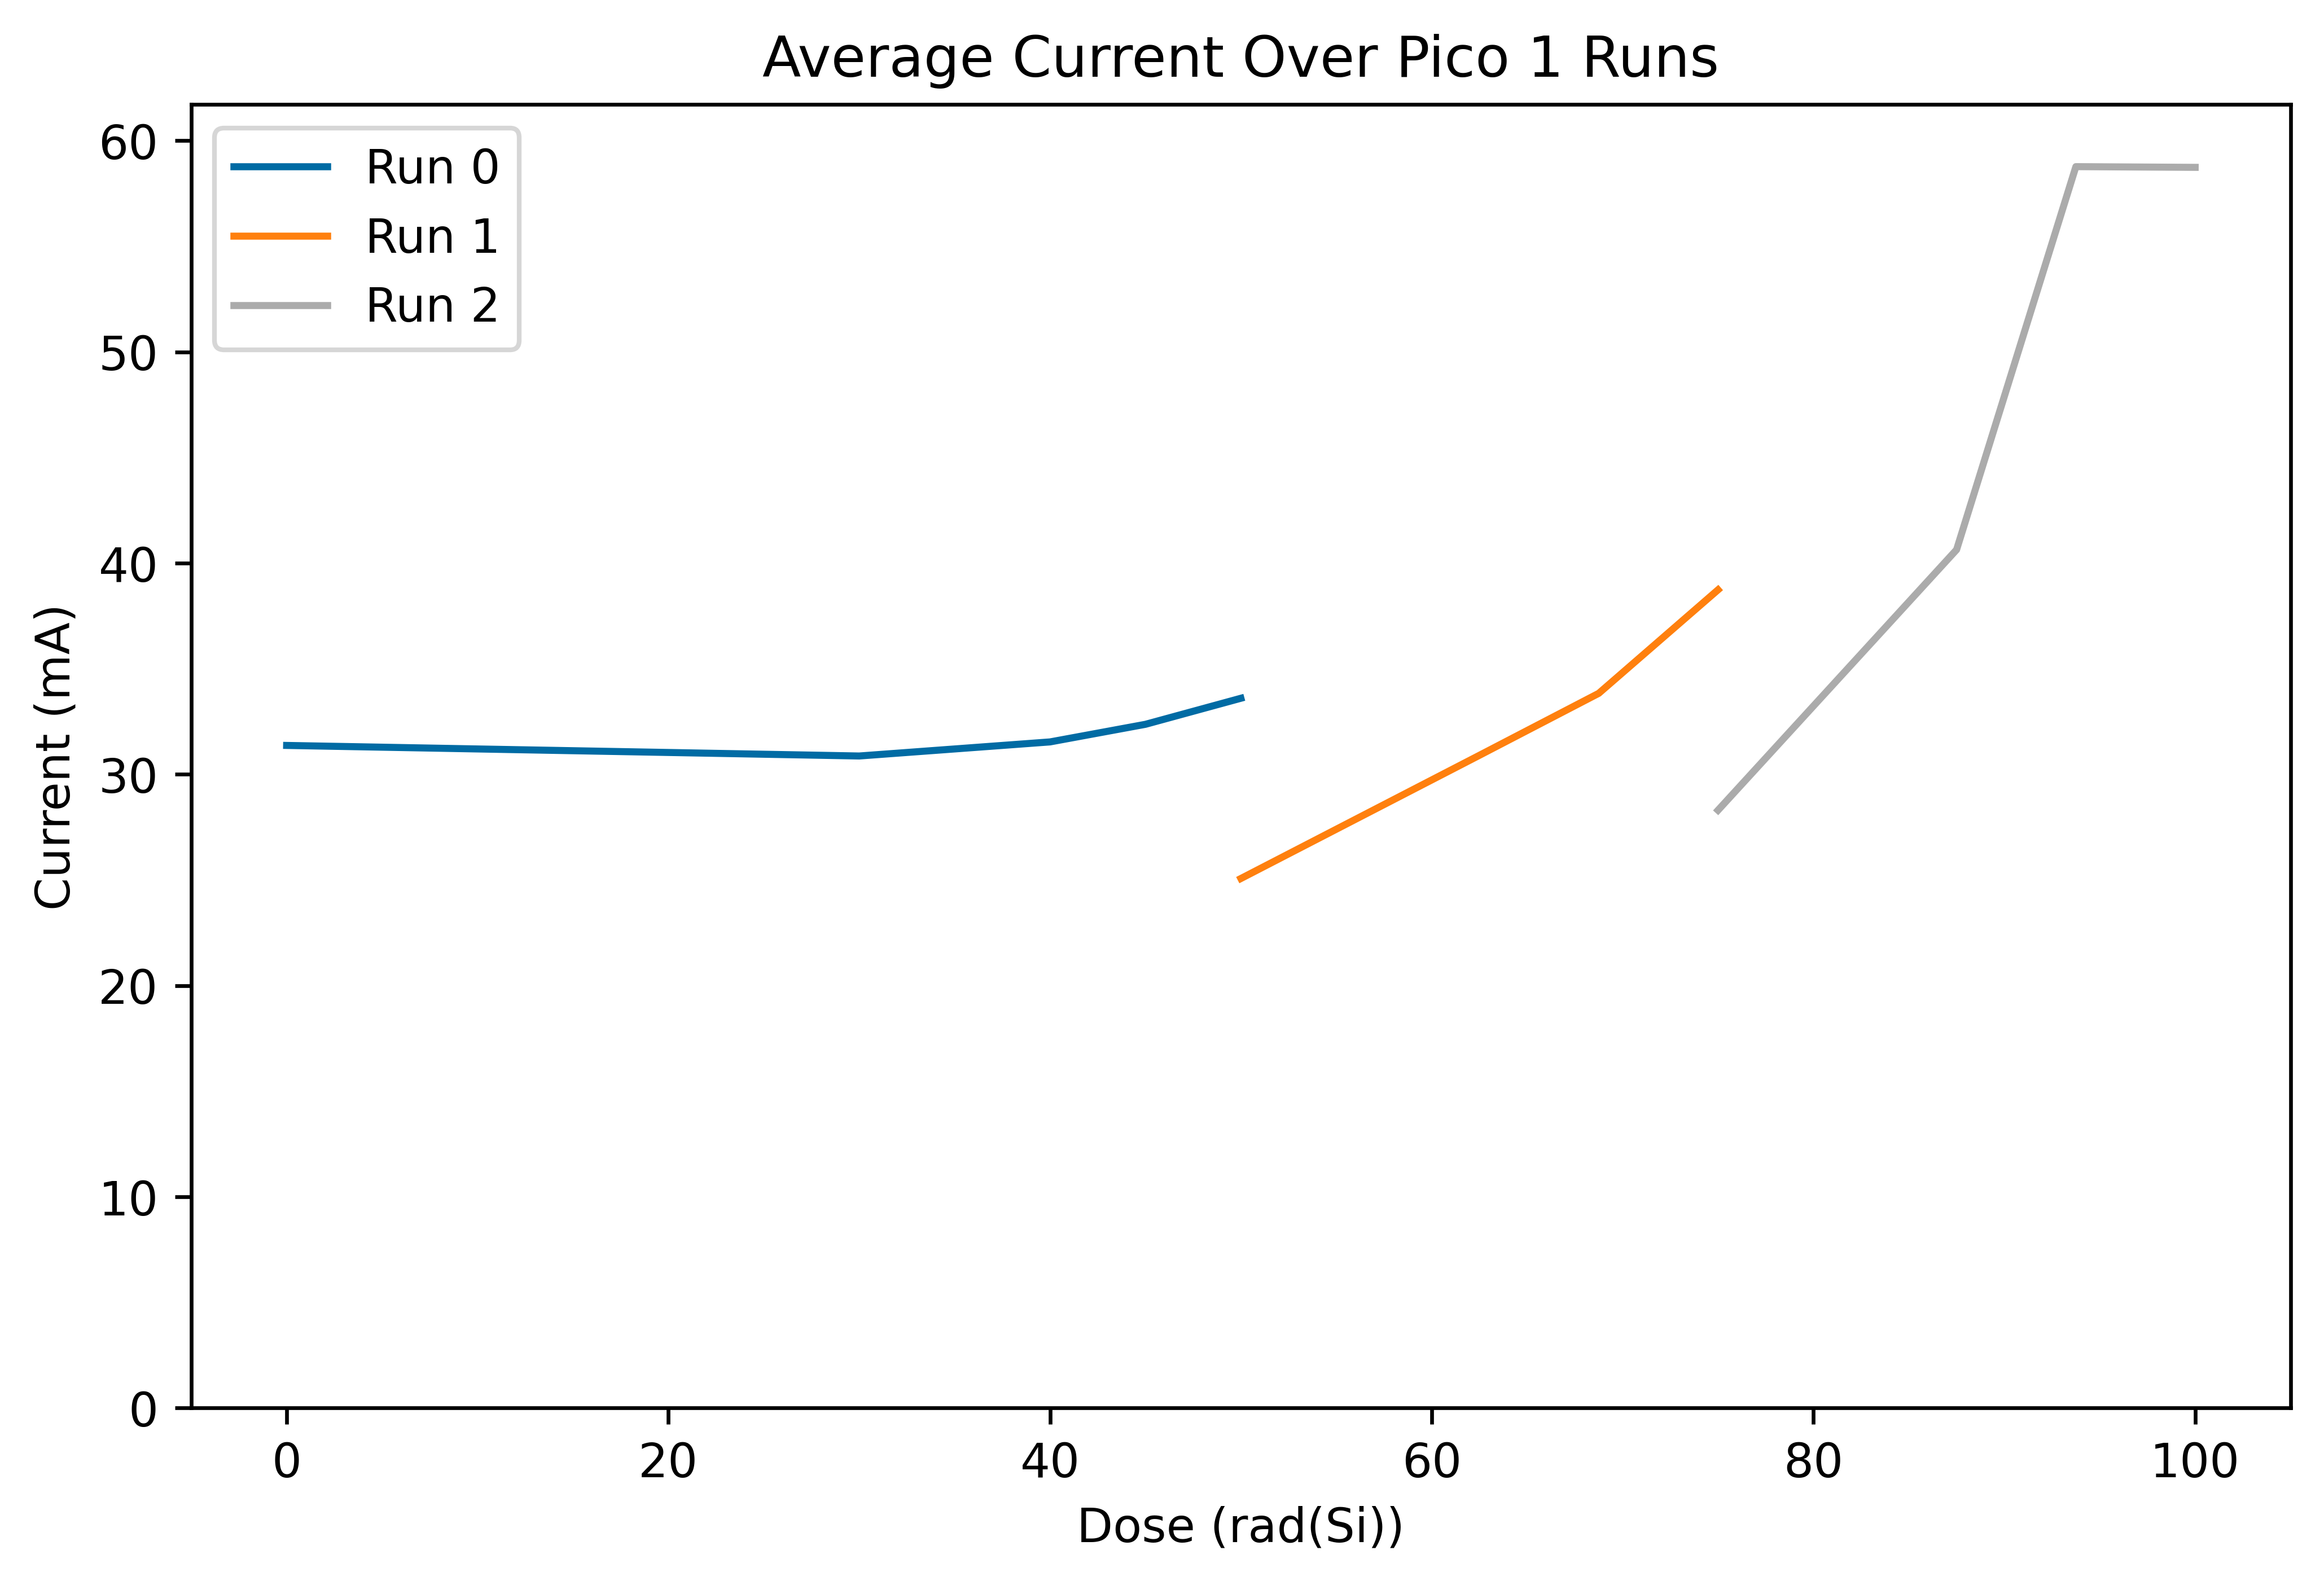

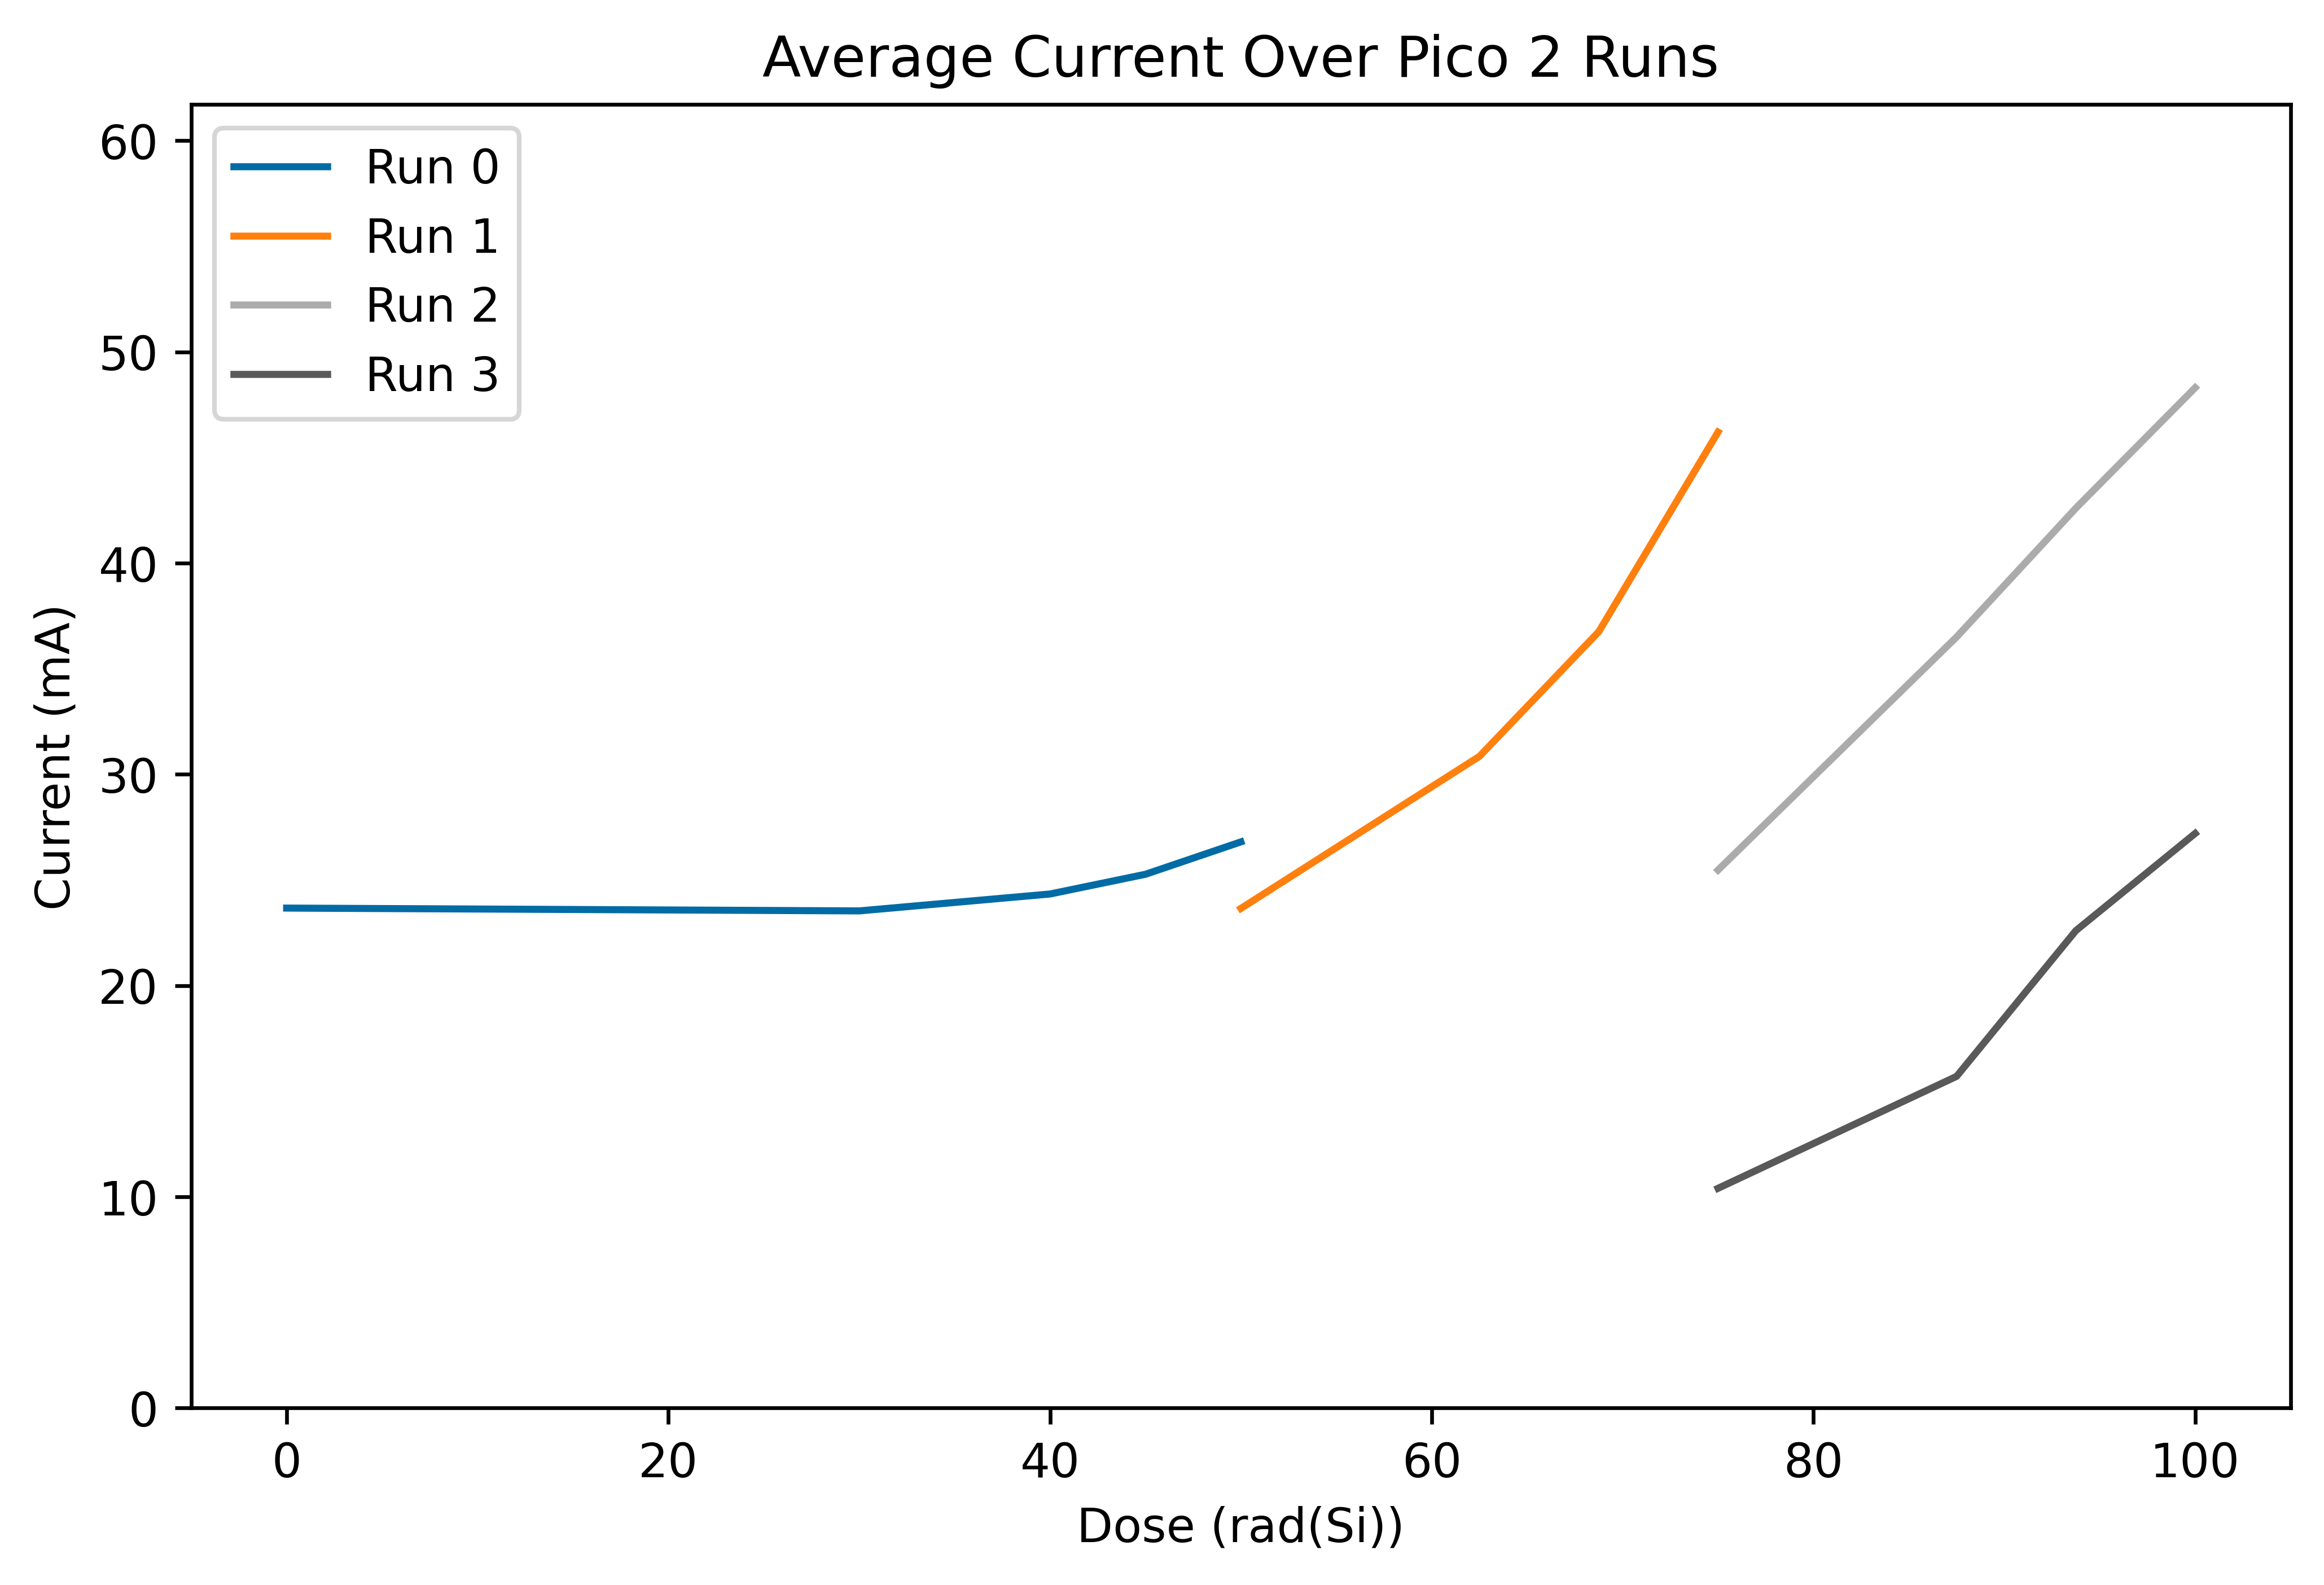

In [10]:
plot_current_curves(pico1_runs, "Average Current Over Pico 1 Runs")
plot_current_curves(pico2_runs + pico2_run_extra, "Average Current Over Pico 2 Runs")


RP2350 5 and 6
RP2040 1 and 2 



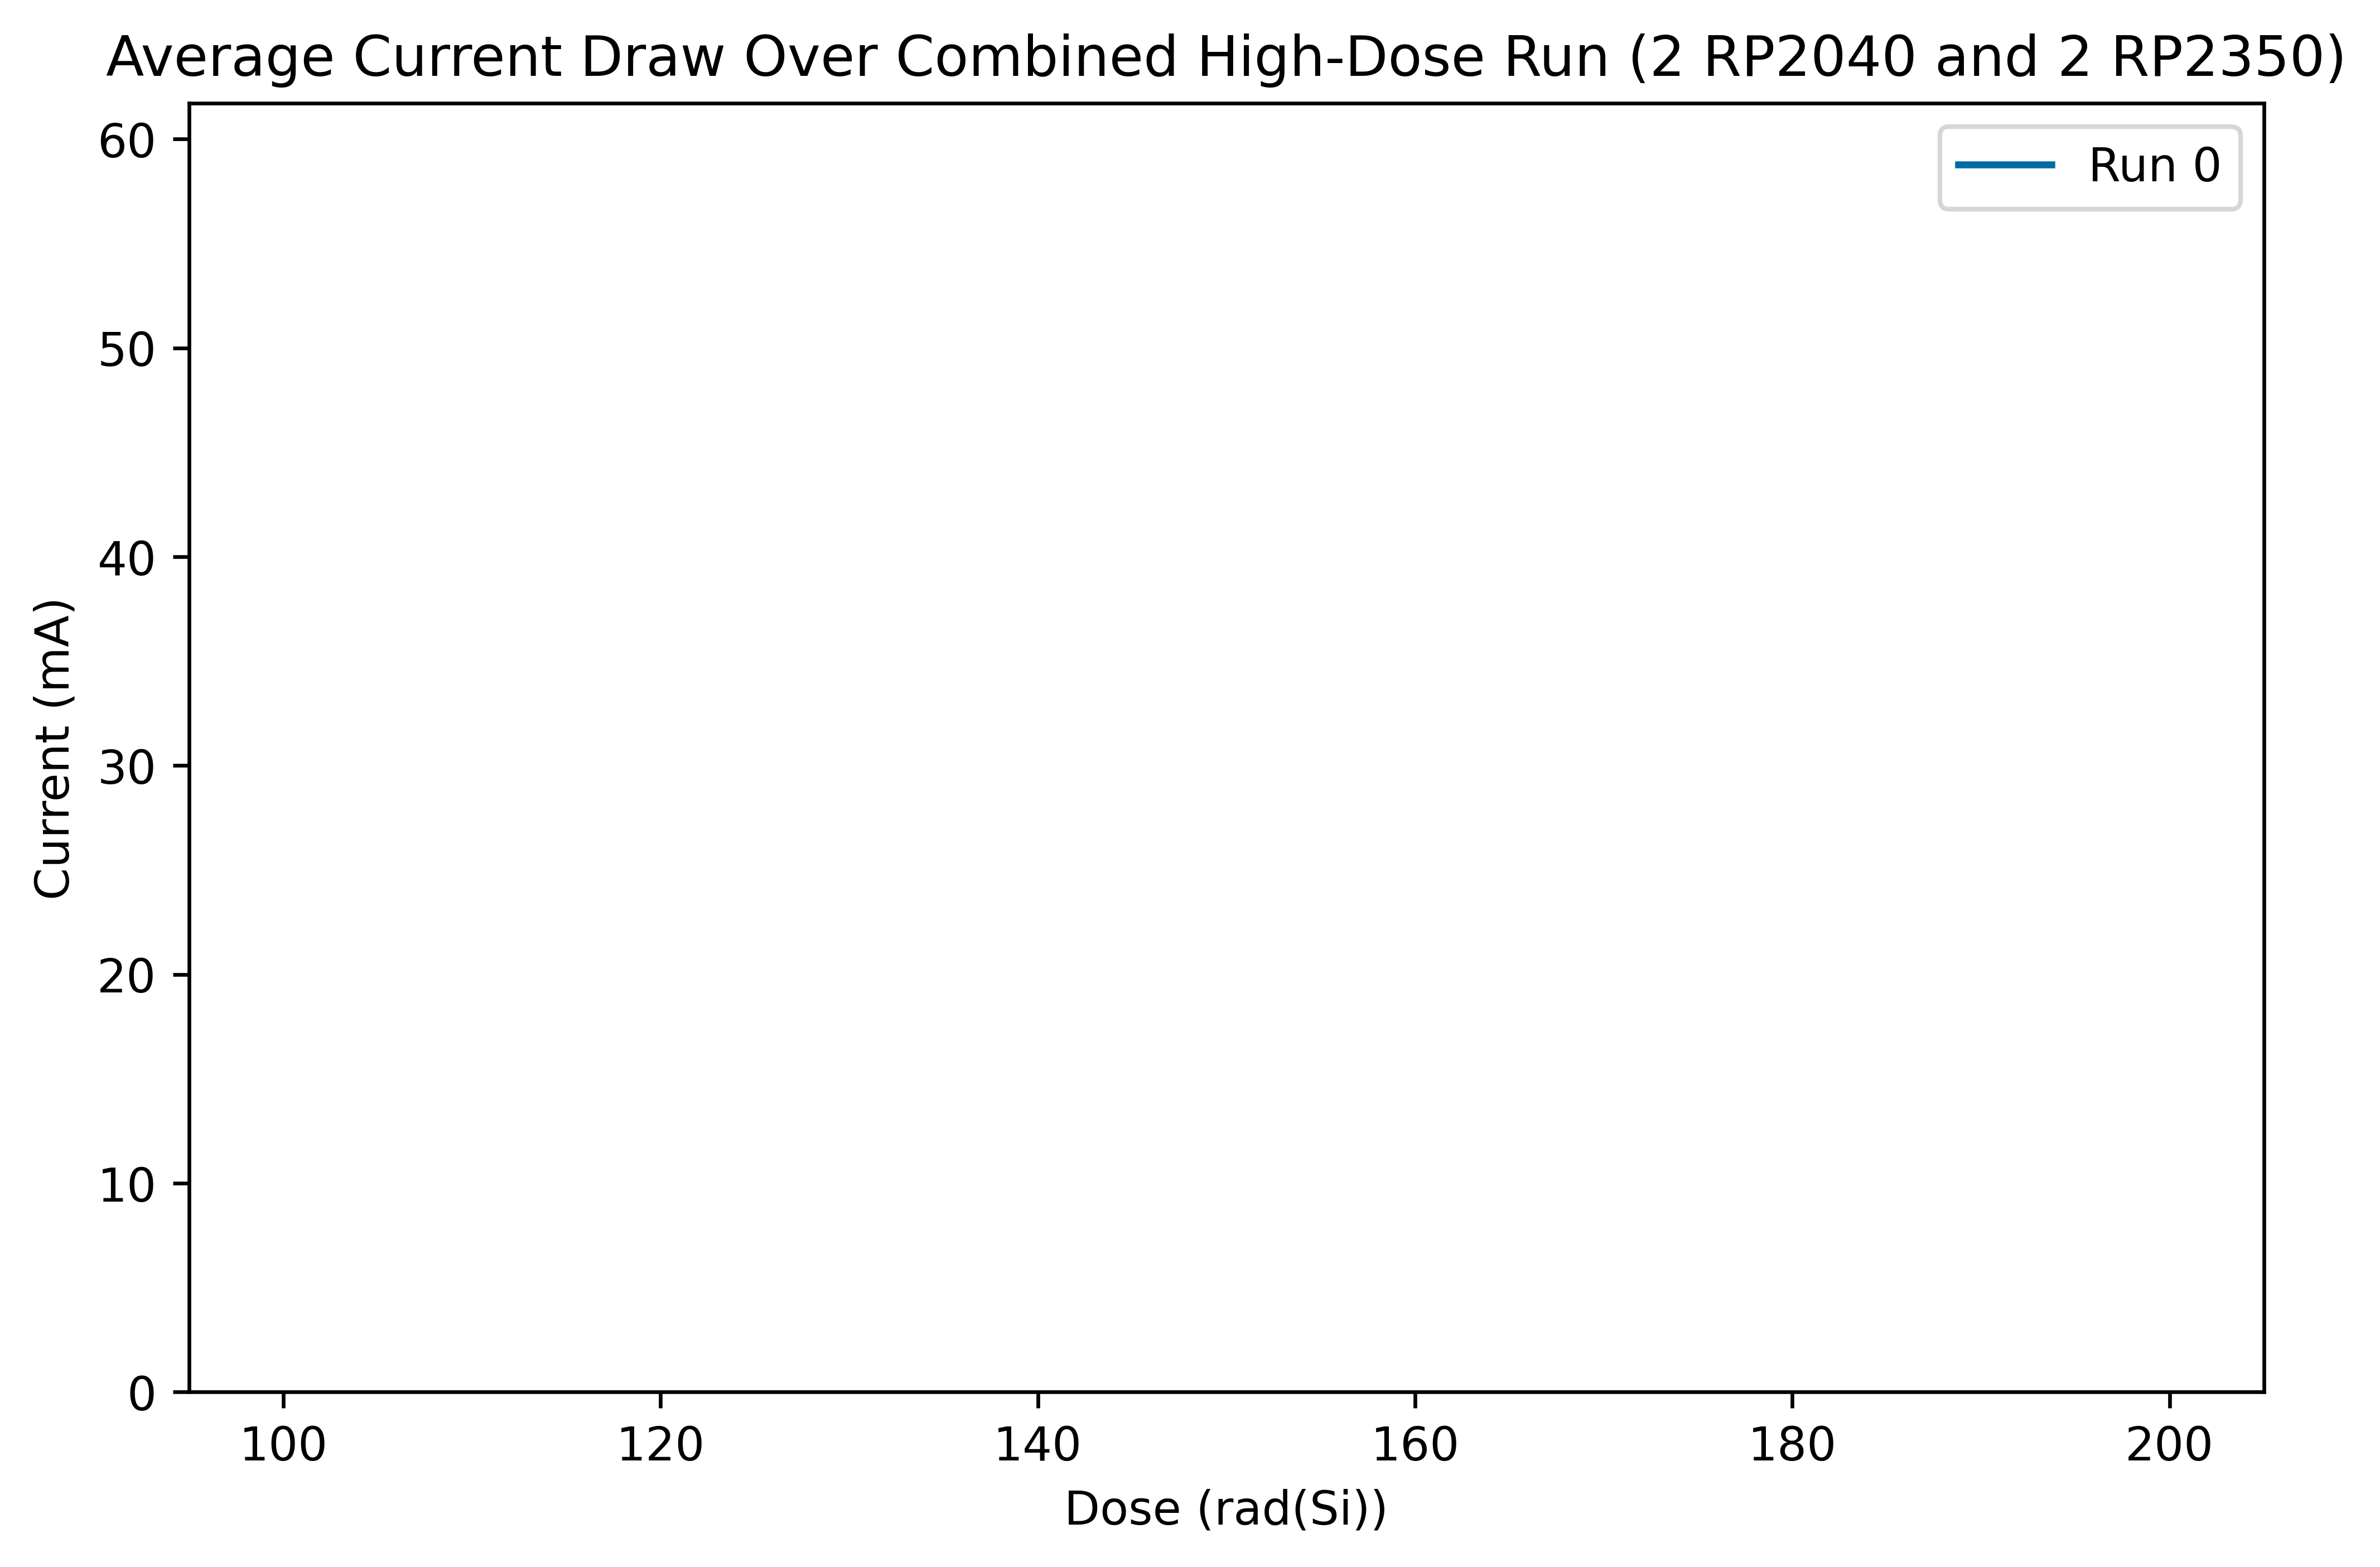

In [11]:
print("""
RP2350 5 and 6
RP2040 1 and 2 
""")
plot_current_curves(final_combo, 
                    "Average Current Draw Over Combined High-Dose Run (2 RP2040 and 2 RP2350)")
